# Project 1 — Gradient Boosting Regressor
## Insurance Premium Prediction

Predicting annual insurance premium from age, BMI, smoker status, region risk score, and claims history.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 800
age = np.random.randint(18, 75, n)
bmi = np.random.normal(27, 5, n).clip(15, 50)
smoker = np.random.choice([0,1], n, p=[0.8,0.2])
region_risk = np.random.uniform(1, 10, n)
claims_history = np.random.poisson(1, n)

premium = (500 + 15*age + 20*bmi + 4000*smoker + 100*region_risk + 300*claims_history
           + 200*smoker*bmi*0.1 + np.random.normal(0, 300, n)).clip(200, None)

df = pd.DataFrame({'age': age, 'bmi': bmi, 'smoker': smoker, 'region_risk': region_risk,
                    'claims_history': claims_history, 'premium': premium})
df.head()


,age,bmi,smoker,region_risk,claims_history,premium
0,56,27.228039,0,3.561061,2,2725.395450
1,69,28.945898,0,8.363860,1,3406.846581
2,46,25.662997,0,5.784395,1,2870.688436
3,32,26.480794,0,8.918764,2,3436.636533
4,60,31.217870,0,6.173016,1,2959.700095


## 2. Preprocessing

In [3]:
X = df.drop('premium', axis=1)
y = df['premium']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Train Model

In [4]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=3,
                                   subsample=0.8, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 267.5594770357151
RMSE: 329.8666768688015
R2 Score: 0.9661973805159833


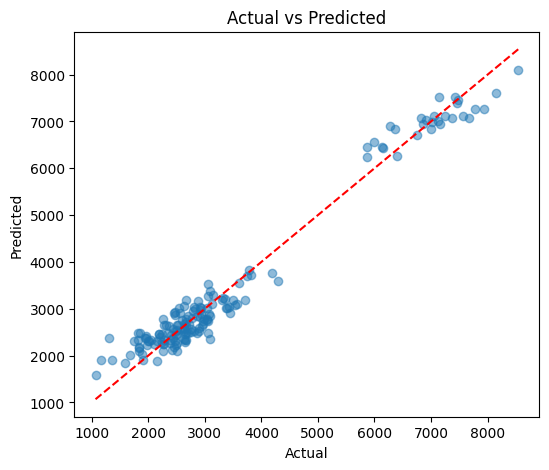

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Check `model.feature_importances_` — smoker status and age likely dominate, matching real insurance pricing logic.
- The premium formula includes a smoker×bmi interaction — check if a plain Linear Regression (no interaction terms) underperforms this model, showing GB's ability to capture interactions automatically.
- Next steps: try `loss='huber'` and compare robustness if you inject a few extreme outlier premiums.

---
# Project 2 — Your Turn
**Dataset:** Taxis dataset (`seaborn.load_dataset('taxis')`) — predict `fare` from `distance`, `passengers`, `pickup`/`dropoff` zones, etc.

```python
import seaborn as sns
taxis = sns.load_dataset('taxis')
```
**Tasks:** handle missing values, encode categorical columns, train Gradient Boosting Regressor, evaluate with MAE/RMSE/R², check feature importances.
